<a href="https://colab.research.google.com/github/Nandhithavijay/pradhi/blob/main/2_COVIDPREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from google.colab import files
files.upload()  # This will open a file selector for you to upload kaggle.json



Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"nandhithavj","key":"01e979435356813eaf147c521e02384f"}'}

In [51]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [52]:
!kaggle datasets list

ref                                                        title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mosapabdelghany/medical-insurance-cost-dataset             Medical Insurance Cost Dataset                        16425  2025-08-24 11:54:36.533000           9385        184  1.0              
zadafiyabhrami/global-crocodile-species-dataset            Global Crocodile Species Dataset                      57473  2025-08-26 08:46:11.950000           6455        190  1.0              
yashdevladdha/uber-ride-analytics-dashboard                Uber Data Analytics Dashboard                      17324552  2025-08-08 11:13:42.920000          52477       1144  1.0              
codebynadiia/gdp-per-country-20202025   

In [ ]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 99% 769M/778M [00:07<00:00, 72.5MB/s]
100% 778M/778M [00:07<00:00, 114MB/s] 


In [47]:
!unzip covid19-radiography-database.zip -d covid19_data

Archive:  covid19-radiography-database.zip
replace covid19_data/COVID-19_Radiography_Dataset/COVID.metadata.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [48]:
!ls covid19_data

COVID-19_Radiography_Dataset


In [ ]:
!ls covid19_data/COVID-19_Radiography_Dataset


 COVID			      Normal.metadata.xlsx
 COVID.metadata.xlsx	      README.md.txt
 Lung_Opacity		     'Viral Pneumonia'
 Lung_Opacity.metadata.xlsx  'Viral Pneumonia.metadata.xlsx'
 Normal


In [ ]:
data_dir = "covid19_data/COVID-19_Radiography_Dataset"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 5️⃣ Set paths
data_dir = "covid19_data/COVID-19_Radiography_Dataset"

# 6️⃣ Data generators with 128x128 image size
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 7️⃣ Build model using MobileNetV2 backbone (pretrained)
base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base model to train faster

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')  # 4 classes: COVID, Normal, Lung_Opacity, Viral Pneumonia
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 8️⃣ Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# 9️⃣ Train the model
history = model.fit(
    train_generator,
    epochs=10,  # max 10 epochs
    validation_data=val_generator,
    callbacks=[early_stop]
)

# ✅ Done! Now you can evaluate:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Found 33866 images belonging to 4 classes.
Found 8464 images belonging to 4 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 635s 594ms/step - accuracy: 0.6786 - loss: 0.8076 - val_accuracy: 0.8524 - val_loss: 0.3920
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 707s 618ms/step - accuracy: 0.7492 - loss: 0.6220 - val_accuracy: 0.8596 - val_loss: 0.3813
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 636s 601ms/step - accuracy: 0.7711 - loss: 0.5776 - val_accuracy: 0.8693 - val_loss: 0.3546
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 639s 603ms/step - accuracy: 0.7713 - loss: 0.5707 - val_accuracy: 0.8828 - val_loss: 0.3207
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 626s 591ms/step - accuracy: 0.7795 - loss: 0.5513 - val_accuracy: 0.8822 - val_loss: 0.3220
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 640s 604ms/step - accuracy: 0.7896 - loss: 0.5281 - val_accuracy: 0.8843 - val_loss: 0.3170
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 609s 575ms/step - accuracy: 0.7917 - loss: 0.5255 - val_accuracy: 0.8782 - val_loss: 0.3396
Epoch 8/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 621s 586ms/step - ac

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


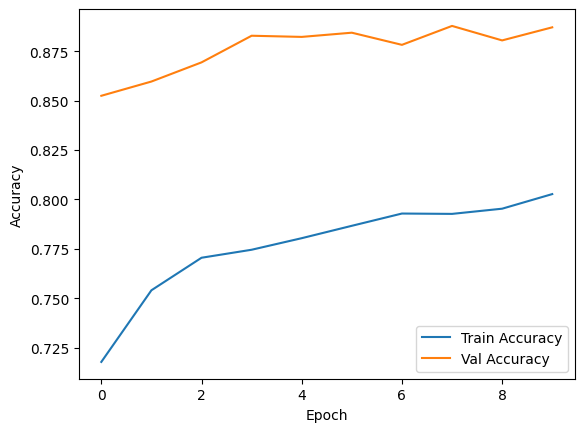

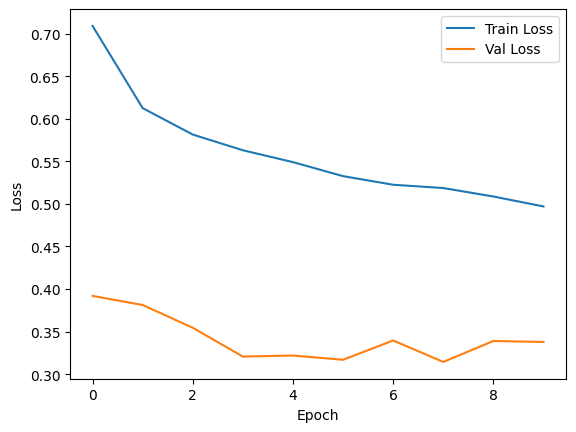

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model.save("covid19_model.h5")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("covid19_model.h5")
print(model.input_shape)



(None, 128, 128, 3)


In [67]:
from tensorflow.keras.preprocessing import image

# Example: predicting a Normal chest X-ray
img_path ="covid19_data/COVID-19_Radiography_Dataset/COVID/images/COVID-220.png"


# Resize the image to 128x128 while loading
img = image.load_img(img_path, target_size=(128, 128))

# Convert to array and scale
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0


In [68]:
target_size=(128, 128)


In [69]:
img = image.load_img(img_path, target_size=(224, 224))


In [70]:
# Make prediction
prediction = model.predict(img_array)

# Get the index of the class with highest probability
class_idx = np.argmax(prediction[0])

# Get class labels from your training generator
labels = list(train_generator.class_indices.keys())
# Define labels in the same order as your model output
labels = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

# Predict
prediction = model.predict(img_array)
class_idx = np.argmax(prediction[0])



# Print the predicted class
print("Predicted Class:", labels[class_idx])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Class: COVID


In [ ]:
# Example: predicting a Normal chest X-ray
img_path = "covid19_data/COVID-19_Radiography_Dataset/Normal/images/Normal-10.png"
img_path = "covid19_data/COVID-19_Radiography_Dataset/COVID/images/COVID-220.png"
